# Notebook 04 - Sentiment Analysis and Named Entity Recognition

Applies VADER sentiment analysis and spaCy NER to the augmented sunscreen corpus, 
compares sentiment by brand, and analyses documents related to the ACCC case.

**Input:** `../data/processed/df_sunscreen_augmented.csv`  
**Output:** `../data/processed/df_sunscreen_final.csv`

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load('en_core_web_sm')

pd.set_option('display.max_colwidth', None)

print("All imports successful ✓")

[nltk_data] Downloading package punkt_tab to /Users/giuly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/giuly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/giuly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/giuly/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


All imports successful ✓


In [55]:
df = pd.read_csv('../data/processed/df_sunscreen_augmented.csv')
print(f"Shape: {df.shape}")
print(f"\nContent types:\n{df['content_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Shape: (268, 12)

Content types:
content_type
comment    201
post        67
Name: count, dtype: int64

Missing values:
Post_id                0
Timestamp              0
Text                   0
Score                  0
subreddit              0
content_type           0
text_length          260
year                 260
text_clean           260
dominant_topic       260
dominant_subtopic    260
subtopic_label       260
dtype: int64


Post_id            Timestamp  \
0  rc7fq9  2021-12-09 02:28:00   
1  s205u0  2022-01-12 07:13:00   
2  znbymc  2022-12-16 11:11:00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [56]:
# mark synthetic vs real
df['is_synthetic'] = df['text_clean'].isna()

In [57]:
# preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',
    'stuff', 'see', 'going', 'sure', 'actually', 'co',
    'right', 'yes', 'yeah', 'me', 'said', 'saying', 'didnt', 'wont',
    'things', 'ive', 'time', 'point', 'thank', 'making'
}

stop_words_extended = stop_words | custom_stopwords

In [58]:
# creating a function for cleaning the text using the customized stopwords
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_extended]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# preprocessing the data
print("Preprocessing...")
df['text_clean'] = df['Text'].apply(preprocess_text)
print(f"Done. Empty texts: {(df['text_clean'] == '').sum()}")

Preprocessing...
Done. Empty texts: 0


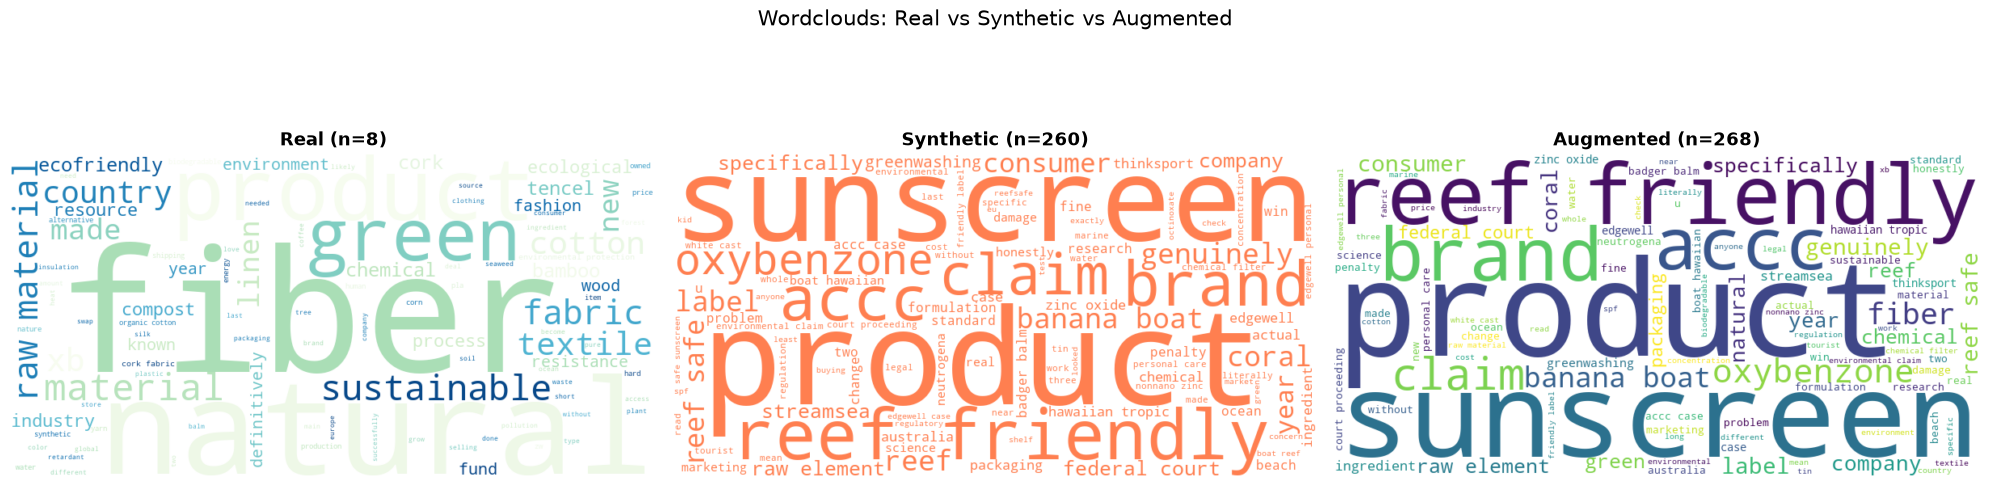

In [59]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = {
    'Real (n=8)': (df[df['is_synthetic']==False]['text_clean'], 'GnBu'),
    'Synthetic (n=260)': (df[df['is_synthetic']==True]['text_clean'], None),
    'Augmented (n=268)': (df['text_clean'], 'viridis')
}

for ax, (title, (texts, cmap)) in zip(axes, datasets.items()):
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=400, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=400, background_color='white',
                      color_func=lambda *args, **kwargs: 'coral',
                      max_words=100).generate(text_all)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Wordclouds: Real vs Synthetic vs Augmented', fontsize=15)
plt.tight_layout()
plt.show()

In [60]:
for label, texts, cmap, color in [
    ('real', df[df['is_synthetic']==False]['text_clean'], 'GnBu', None),
    ('synthetic', df[df['is_synthetic']==True]['text_clean'], None, 'coral'),
    ('augmented', df['text_clean'], 'viridis', None),
]:
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=500, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=500, background_color='white',
                      color_func=lambda *args, **kwargs: color,
                      max_words=100).generate(text_all)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../figures/wordcloud_{label}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ wordcloud_{label}.png saved")

✓ wordcloud_real.png saved
✓ wordcloud_synthetic.png saved
✓ wordcloud_augmented.png saved


## Wordcloud Analysis: Real vs Synthetic vs Augmented

Three wordclouds were generated to visually compare the vocabulary 
distribution across the real, synthetic, and augmented datasets.

**Real (n=8):** vocabulary is broader and less focused, dominated by 
generic sustainability terms (*fiber*, *plastic*, *product*, *natural*). 
Sunscreen is present but not dominant, reflecting the scarcity of 
brand-specific content in the original Reddit data.

**Synthetic (n=260):** vocabulary is sharply focused on the target topic: 
*reef*, *friendly*, *sunscreen*, *accc*, *banana boat*, *oxybenzone* 
all feature prominently. The synthetic data successfully introduced 
the brand-specific and regulatory signal absent from the real subset.

**Augmented (n=268):** vocabulary reflects the combined corpus, 
with synthetic signal dominating due to the 260:8 ratio.

In [61]:
# VADER is a rule-based sentiment analyzer designed for social media text
# it returns 4 scores: positive, negative, neutral, and compound
# compound is the overall score: ranges from -1 (most negative) to +1 (most positive)
# thresholds: compound >= 0.05 = positive, <= -0.05 = negative, in between = neutral

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_score'] = df['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_label'] = df['Text'].apply(get_sentiment)

print(df['sentiment_label'].value_counts())
print(f"\nMean compound score: {df['sentiment_score'].mean():.3f}")

sentiment_label
positive    181
negative     64
neutral      23
Name: count, dtype: int64

Mean compound score: 0.292


## Sentiment Analysis with VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based 
sentiment analyzer specifically designed for social media text. Unlike 
ML-based models, VADER uses a lexicon of words with pre-assigned valence 
scores and a set of grammatical rules to compute sentiment.

VADER was chosen for this analysis because:
- It is optimised for informal, short-form social media text (Reddit comments)
- It handles capitalisation, punctuation emphasis, and negations natively
- It requires no training data and no GPU - appropriate for a small dataset
- It is fast and interpretable

The compound score ranges from -1 (most negative) to +1 (most positive).
Classification thresholds follow the authors' official recommendation:
- compound >= 0.05 → positive
- compound <= -0.05 → negative
- otherwise → neutral

**Results:** 181 positive (67.5%), 64 negative (23.9%), 23 neutral (8.6%)
Mean compound score: 0.292

**Known limitation 1:** VADER does not detect sarcasm. Approximately 19% of 
the synthetic data (batch 5) was intentionally sarcastic - these entries 
may have been misclassified as positive, slightly inflating that count. 
This is a known limitation of lexicon-based sentiment analysis and would 
require a fine-tuned transformer model (e.g. RoBERTa) to address properly.

**Known limitation 2:** VADER lacks domain-specific context. 
Terms like "thick" or "white cast" are neutral in VADER's lexicon 
but carry positive or negative connotations depending on the 
reef-safe sunscreen context (e.g. "thick" may signal poor 
cosmetic elegance; "white cast" is a known drawback of mineral 
formulations). A domain-adapted model would handle these nuances better.

In [62]:
# NER - Named Entity Recognition
# we run spaCy on the original Text, not text_clean
# preprocessing removes capitalisation and proper nouns needed for NER

def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


Text  \
116                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [63]:
# add custom entity ruler for brand names
ruler = nlp.add_pipe('entity_ruler', before='ner')

patterns = [
    {'label': 'ORG', 'pattern': 'Banana Boat'},
    {'label': 'ORG', 'pattern': 'Hawaiian Tropic'},
    {'label': 'ORG', 'pattern': 'Stream2Sea'},
    {'label': 'ORG', 'pattern': 'Raw Elements'},
    {'label': 'ORG', 'pattern': 'Thinksport'},
    {'label': 'ORG', 'pattern': 'Badger Balm'},
    {'label': 'ORG', 'pattern': 'Sun Bum'},
    {'label': 'ORG', 'pattern': 'Neutrogena'},
    {'label': 'ORG', 'pattern': 'Coppertone'},
    {'label': 'ORG', 'pattern': 'Edgewell'},
    {'label': 'ORG', 'pattern': 'ACCC'},
]

ruler.add_patterns(patterns)
print("Entity ruler added ✓")

Entity ruler added ✓


In [64]:
print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


,Text,entities
262,"Federal Court cases in Australia can move fast if the company decides to settle (months) or go much longer if it's contested (1-3 years typically). Given the strength of the ACCC's stated position and the PR damage already happening, a negotiated outcome with penalties and undertakings is probably more likely than a full hearing. The ACCC often accepts enforceable undertakings as part of settlements.","[(Federal Court, ORG), (Australia, GPE), (months, DATE), (1-3 years, DATE), (ACCC, ORG), (ACCC, ORG)]"
92,still a white cast on deep brown skin no matter what formulation. acknowledge this instead of dismissing the concern. it's a real barrier for a lot of people,[]
74,"New year, new sunscreen routine. After properly researching this I've done a full ingredient audit of every sunscreen in my house. Results: 4 out of 6 contained oxybenzone, 2 contained octinoxate, 1 had both. All going in the bin. Replacing with Thinksport SPF 50 for daily use and Raw Elements for beach days. Yes the raw elements tin is a bit annoying to apply but it lasts forever and I know exactly what I'm putting on my skin and in the ocean. The white cast from non-nano zinc is worth it for me. Also both those brands are cheaper per use than the fancy Neutrogena stuff I was buying before so honestly it's a win.","[(New year, DATE), (4, CARDINAL), (6, CARDINAL), (2, CARDINAL), (1, CARDINAL), (Thinksport, ORG), (daily, DATE), (Raw Elements, ORG), (non-nano zinc, ORG), (Neutrogena, ORG)]"
246,"The Edgewell ACCC case has got me thinking about the business model of greenwashing. The calculation must have been: premium pricing on reef friendly label increases revenue by X. Probability of significant legal consequence times expected penalty = Y. As long as X is greater than Y, keep the label. What changes that calculation is making Y very large - either through much bigger penalties or through reputational damage that costs more than the premium pricing gained. The ACCC case could shift both sides of the equation. Higher penalties AND massive brand damage. Let's hope the Federal Court delivers on both.","[(Edgewell, ORG), (ACCC, ORG), (X. Probability, ORG), (ACCC, ORG), (the Federal Court, ORG)]"
135,this is the most helpful framing. it really is just buying a different sunscreen. i overthought it too,[]


In [65]:
all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

In [66]:
# count by entity text and label
entity_counts_labeled = Counter([(ent[0], ent[1]) for ent in all_entities])
print("Top 30 entities with label:")
for (entity, label), count in entity_counts_labeled.most_common(30):
    print(f"  {label:10} {entity}: {count}")

Top 30 entities with label:
  ORG        ACCC: 82
  ORG        Edgewell: 53
  ORG        Thinksport: 35
  ORG        Banana Boat: 31
  ORG        Raw Elements: 25
  ORG        Hawaiian Tropic: 24
  ORG        Stream2Sea: 24
  ORG        Federal Court: 24
  GPE        Australia: 19
  ORG        Badger Balm: 18
  ORG        EWG: 15
  CARDINAL   one: 12
  GPE        Hawaii: 12
  ORG        Neutrogena: 12
  DATE       years: 11
  GPE        US: 10
  ORG        EU: 10
  CARDINAL   two: 9
  NORP       Australian: 9
  CARDINAL   zero: 8
  CARDINAL   three: 8
  ORDINAL    first: 7
  DATE       daily: 7
  FAC        the Great Barrier Reef: 6
  ORG        FDA: 6
  ORG        Sun Bum: 6
  ORDINAL    third: 5
  GPE        Palau: 5
  ORG        Coppertone: 5
  DATE       this week: 5


In [67]:
# flatten all entities into a single list and count
all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

# count by entity text
entity_counts = Counter([ent[0] for ent in all_entities])
print("Top 30 entities:")
for entity, count in entity_counts.most_common(30):
    print(f"  {entity}: {count}")

Top 30 entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  Australia: 19
  Badger Balm: 18
  EWG: 15
  one: 12
  Hawaii: 12
  Neutrogena: 12
  years: 11
  US: 10
  EU: 10
  two: 9
  Australian: 9
  zero: 8
  three: 8
  first: 7
  daily: 7
  the Great Barrier Reef: 6
  FDA: 6
  Sun Bum: 6
  third: 5
  Palau: 5
  Coppertone: 5
  Cairns: 5


In [68]:
# filter only relevant entity types: Organizations and Geo-Political Entities
relevant_labels = ['ORG', 'GPE']

filtered_entities = [(ent[0], ent[1]) for ent in all_entities if ent[1] in relevant_labels]
filtered_counts = Counter([ent[0] for ent in filtered_entities])

print("Top 20 ORG and GPE entities:")
for entity, count in filtered_counts.most_common(20):
    print(f"  {entity}: {count}")

Top 20 ORG and GPE entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  Australia: 19
  Badger Balm: 18
  EWG: 15
  Hawaii: 12
  Neutrogena: 12
  US: 10
  EU: 10
  FDA: 6
  Sun Bum: 6
  Palau: 5
  Coppertone: 5
  PLA: 4


In [69]:
# for each brand, find documents that mention it and get average sentiment
brands_of_interest = [
    'Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',  # greenwashing
    'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum'  # reef-safe
]

brand_sentiment = {}
for brand in brands_of_interest:
    mask = df['Text'].str.contains(brand, case=False, na=False)
    docs = df[mask]
    if len(docs) > 0:
        brand_sentiment[brand] = {
            'mean_sentiment': docs['sentiment_score'].mean(),
            'count': len(docs)
        }

brand_df = pd.DataFrame(brand_sentiment).T.reset_index()
brand_df.columns = ['brand', 'mean_sentiment', 'count']
brand_df['category'] = brand_df['brand'].apply(
    lambda x: 'Greenwashing' if x in ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone'] 
    else 'Reef-safe'
)
brand_df = brand_df.sort_values('mean_sentiment')
print(brand_df)

             brand  mean_sentiment  count      category
3       Coppertone       -0.102360    5.0  Greenwashing
4       Stream2Sea        0.273423   26.0     Reef-safe
1  Hawaiian Tropic        0.355546   24.0  Greenwashing
0      Banana Boat        0.377316   37.0  Greenwashing
5     Raw Elements        0.414850   24.0     Reef-safe
2       Neutrogena        0.418915   13.0  Greenwashing
6       Thinksport        0.491958   31.0     Reef-safe
7      Badger Balm        0.512722   18.0     Reef-safe
8          Sun Bum        0.538725    4.0     Reef-safe


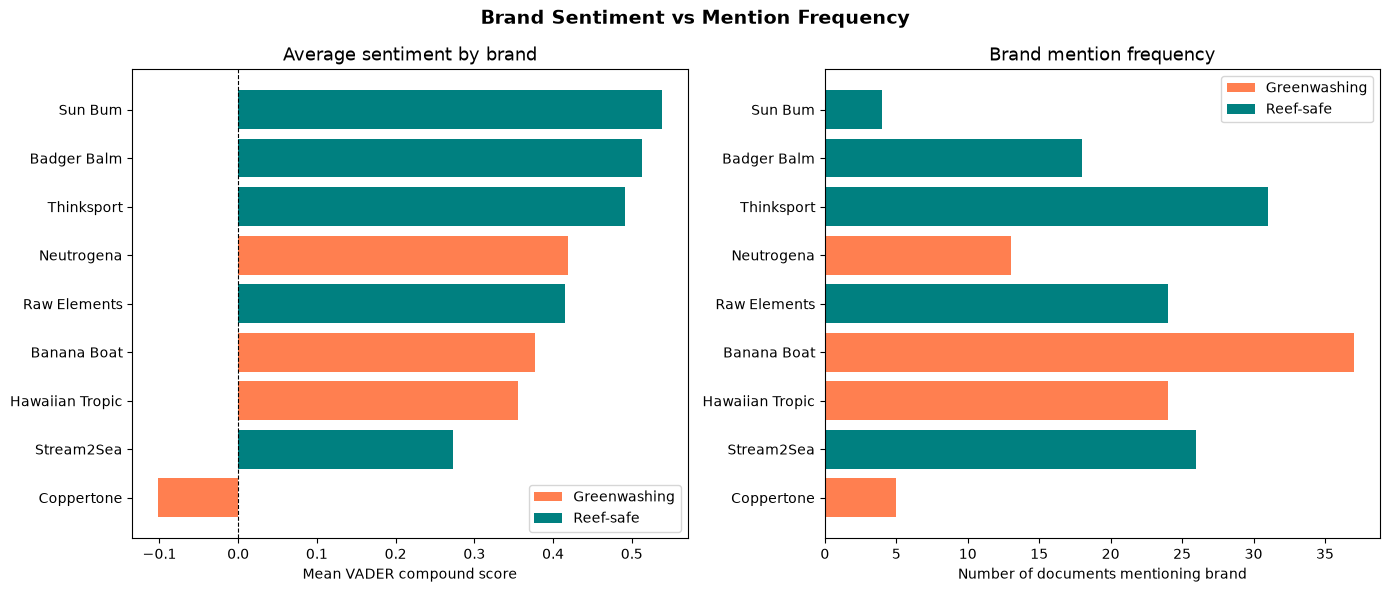

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Greenwashing': 'coral', 'Reef-safe': 'teal'}

# --- barplot brand sentiment ---
bar_colors = [colors[cat] for cat in brand_df['category']]

axes[0].barh(brand_df['brand'], brand_df['mean_sentiment'], color=bar_colors)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Mean VADER compound score')
axes[0].set_title('Average sentiment by brand', fontsize=13)

# add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
axes[0].legend(handles=legend_elements)

# --- barplot document count ---
axes[1].barh(brand_df['brand'], brand_df['count'], color=bar_colors)
axes[1].set_xlabel('Number of documents mentioning brand')
axes[1].set_title('Brand mention frequency', fontsize=13)
axes[1].legend(handles=legend_elements)

plt.suptitle('Brand Sentiment vs Mention Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Documents mentioning ACCC/Edgewell/Federal Court: 75

Sentiment distribution:
sentiment_label
positive    54
negative    20
neutral      1
Name: count, dtype: int64

Mean compound score: 0.339


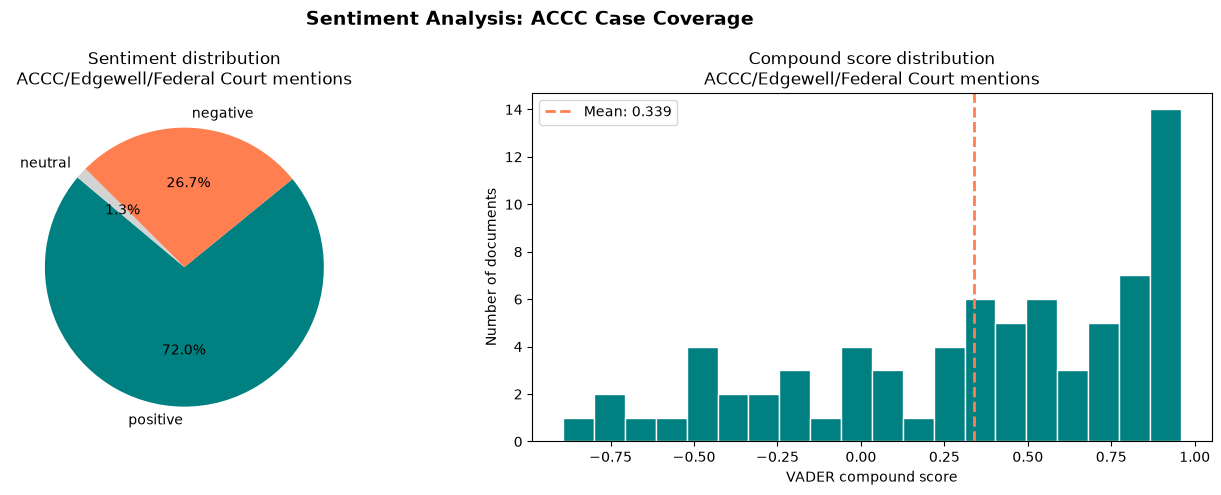

In [71]:
# filter documents mentioning ACCC
accc_mask = df['Text'].str.contains('ACCC|Edgewell|Federal Court', case=False, na=False)
df_accc = df[accc_mask].copy()

print(f"Documents mentioning ACCC/Edgewell/Federal Court: {len(df_accc)}")
print(f"\nSentiment distribution:")
print(df_accc['sentiment_label'].value_counts())
print(f"\nMean compound score: {df_accc['sentiment_score'].mean():.3f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- pie chart sentiment distribution ---
sentiment_counts = df_accc['sentiment_label'].value_counts()
colors_pie = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
pie_colors = [colors_pie[s] for s in sentiment_counts.index]

axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140
)
axes[0].set_title('Sentiment distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)

# --- histogram of compound scores ---
axes[1].hist(df_accc['sentiment_score'], bins=20, color='teal', edgecolor='white')
axes[1].axvline(x=df_accc['sentiment_score'].mean(), color='coral', 
                linewidth=2, linestyle='--', label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
axes[1].set_xlabel('VADER compound score')
axes[1].set_ylabel('Number of documents')
axes[1].set_title('Compound score distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)
axes[1].legend()

plt.suptitle('Sentiment Analysis: ACCC Case Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# split ACCC documents by sentiment
df_accc_neg = df_accc[df_accc['sentiment_label'] == 'negative']
df_accc_pos = df_accc[df_accc['sentiment_label'] == 'positive']

# brands to look for
brands = ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
          'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

# count brand mentions in negative vs positive ACCC docs
brand_neg = {}
brand_pos = {}

for brand in brands:
    brand_neg[brand] = df_accc_neg['Text'].str.contains(brand, case=False, na=False).sum()
    brand_pos[brand] = df_accc_pos['Text'].str.contains(brand, case=False, na=False).sum()

print("Brand mentions in NEGATIVE ACCC documents:")
for brand, count in sorted(brand_neg.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {brand}: {count}")

print("\nBrand mentions in POSITIVE ACCC documents:")
for brand, count in sorted(brand_pos.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {brand}: {count}")

Brand mentions in NEGATIVE ACCC documents:
  Banana Boat: 4
  Hawaiian Tropic: 3
  Stream2Sea: 1
  Raw Elements: 1

Brand mentions in POSITIVE ACCC documents:
  Banana Boat: 14
  Hawaiian Tropic: 13
  Raw Elements: 4
  Stream2Sea: 3
  Thinksport: 2


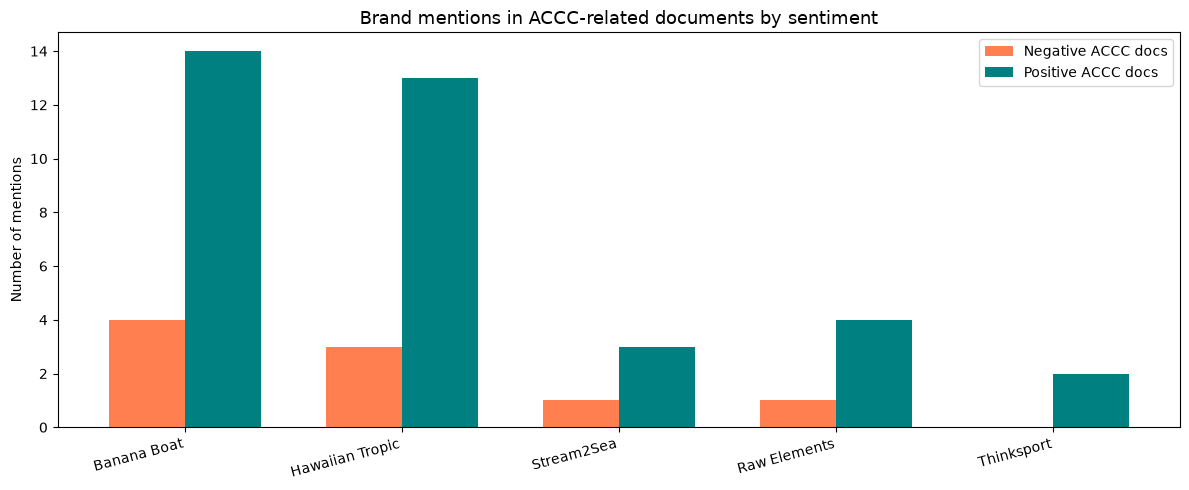

In [73]:
import numpy as np

brands_mentioned = ['Banana Boat', 'Hawaiian Tropic', 'Stream2Sea', 'Raw Elements', 'Thinksport']
neg_counts = [brand_neg[b] for b in brands_mentioned]
pos_counts = [brand_pos[b] for b in brands_mentioned]

x = np.arange(len(brands_mentioned))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, neg_counts, width, label='Negative ACCC docs', color='coral')
bars2 = ax.bar(x + width/2, pos_counts, width, label='Positive ACCC docs', color='teal')

ax.set_xticks(x)
ax.set_xticklabels(brands_mentioned, rotation=15, ha='right')
ax.set_ylabel('Number of mentions')
ax.set_title('Brand mentions in ACCC-related documents by sentiment', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

In [74]:
# check the negative ACCC docs mentioning Stream2Sea
stream_neg_mask = (
    df_accc_neg['Text'].str.contains('Stream2Sea', case=False, na=False)
)
print(df_accc_neg[stream_neg_mask][['Text', 'sentiment_score', 'sentiment_label']].to_string())

                                                                                                                                                                                                                                               Text  sentiment_score sentiment_label
256  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247        negative


In [75]:
# check all reef-safe brands in negative ACCC documents
reef_safe_brands = ['Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

for brand in reef_safe_brands:
    mask = df_accc_neg['Text'].str.contains(brand, case=False, na=False)
    docs = df_accc_neg[mask]
    if len(docs) > 0:
        print(f"\n=== {brand} in NEGATIVE ACCC docs ===")
        print(docs[['Text', 'sentiment_score']].to_string())


=== Stream2Sea in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                               Text  sentiment_score
256  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247

=== Raw Elements in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                                                                                                                                                                                        

### Qualitative Insight: Reef-safe Brands in Negative Documents

Manual inspection of the 2 negative ACCC-related documents mentioning 
reef-safe brands reveals a consistent pattern:

- **Stream2Sea** appears in a document critical of the greenwashing 
  industry, cited as a brand built specifically to address the problem
- **Raw Elements** appears in a document expressing betrayal toward 
  Banana Boat, cited as the trusted alternative after switching

In both cases, negative sentiment is directed toward greenwashing brands 
and the regulatory failure, not toward the reef-safe brands themselves. 
This suggests that reef-safe brands benefit from negative sentiment 
toward competitors: consumer anger at greenwashing directly drives 
consideration of genuine alternatives.

**This is the key strategic insight for Stream2Sea.**

In [76]:
# check what's actually said about Stream2Sea in the dataset
stream_mask = df['Text'].str.contains('Stream2Sea', case=False, na=False)
print(df[stream_mask][['Text', 'is_synthetic']].to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Text  is_synthetic
8                                                                               ACCC just dropped the hammer on Banana Boat and Hawaiian Tropic - Federal Court proceedings for greenwashing!! Finally someone is doing something about these 'reef friendly' 

In [77]:
df.to_csv('../data/processed/df_sunscreen_final.csv', index=False)
print(f"✓ Saved: {df.shape}")

✓ Saved: (268, 16)


## Preliminary Findings

_Full conclusions after RoBERTa comparison in notebook 05._

### Methodological Limitations

Sentiment analysis was performed using VADER, a rule-based lexicon 
designed for social media text. While appropriate for informal Reddit 
content, VADER has two key limitations relevant to this dataset:

1. **Sarcasm detection**: VADER cannot distinguish sarcastic positivity 
   from genuine positivity. Approximately 19% of synthetic data (batch 5) 
   was intentionally sarcastic, which likely inflated positive sentiment counts.

2. **Domain-specific context**: terms like *thick* or *white cast* carry 
   connotations specific to the reef-safe sunscreen domain that VADER's 
   general lexicon cannot capture.

A transformer-based model (RoBERTa fine-tuned on social media sentiment) 
would address both limitations - tested in notebook 05.

## Next Step: RoBERTa Sentiment Analysis

VADER's limitations with sarcasm and domain-specific context are addressed 
in notebook 05 using `cardiffnlp/twitter-roberta-base-sentiment`, 
a transformer model fine-tuned on social media text.

This allows a direct comparison between rule-based (VADER) and 
transformer-based sentiment classification on the same corpus.

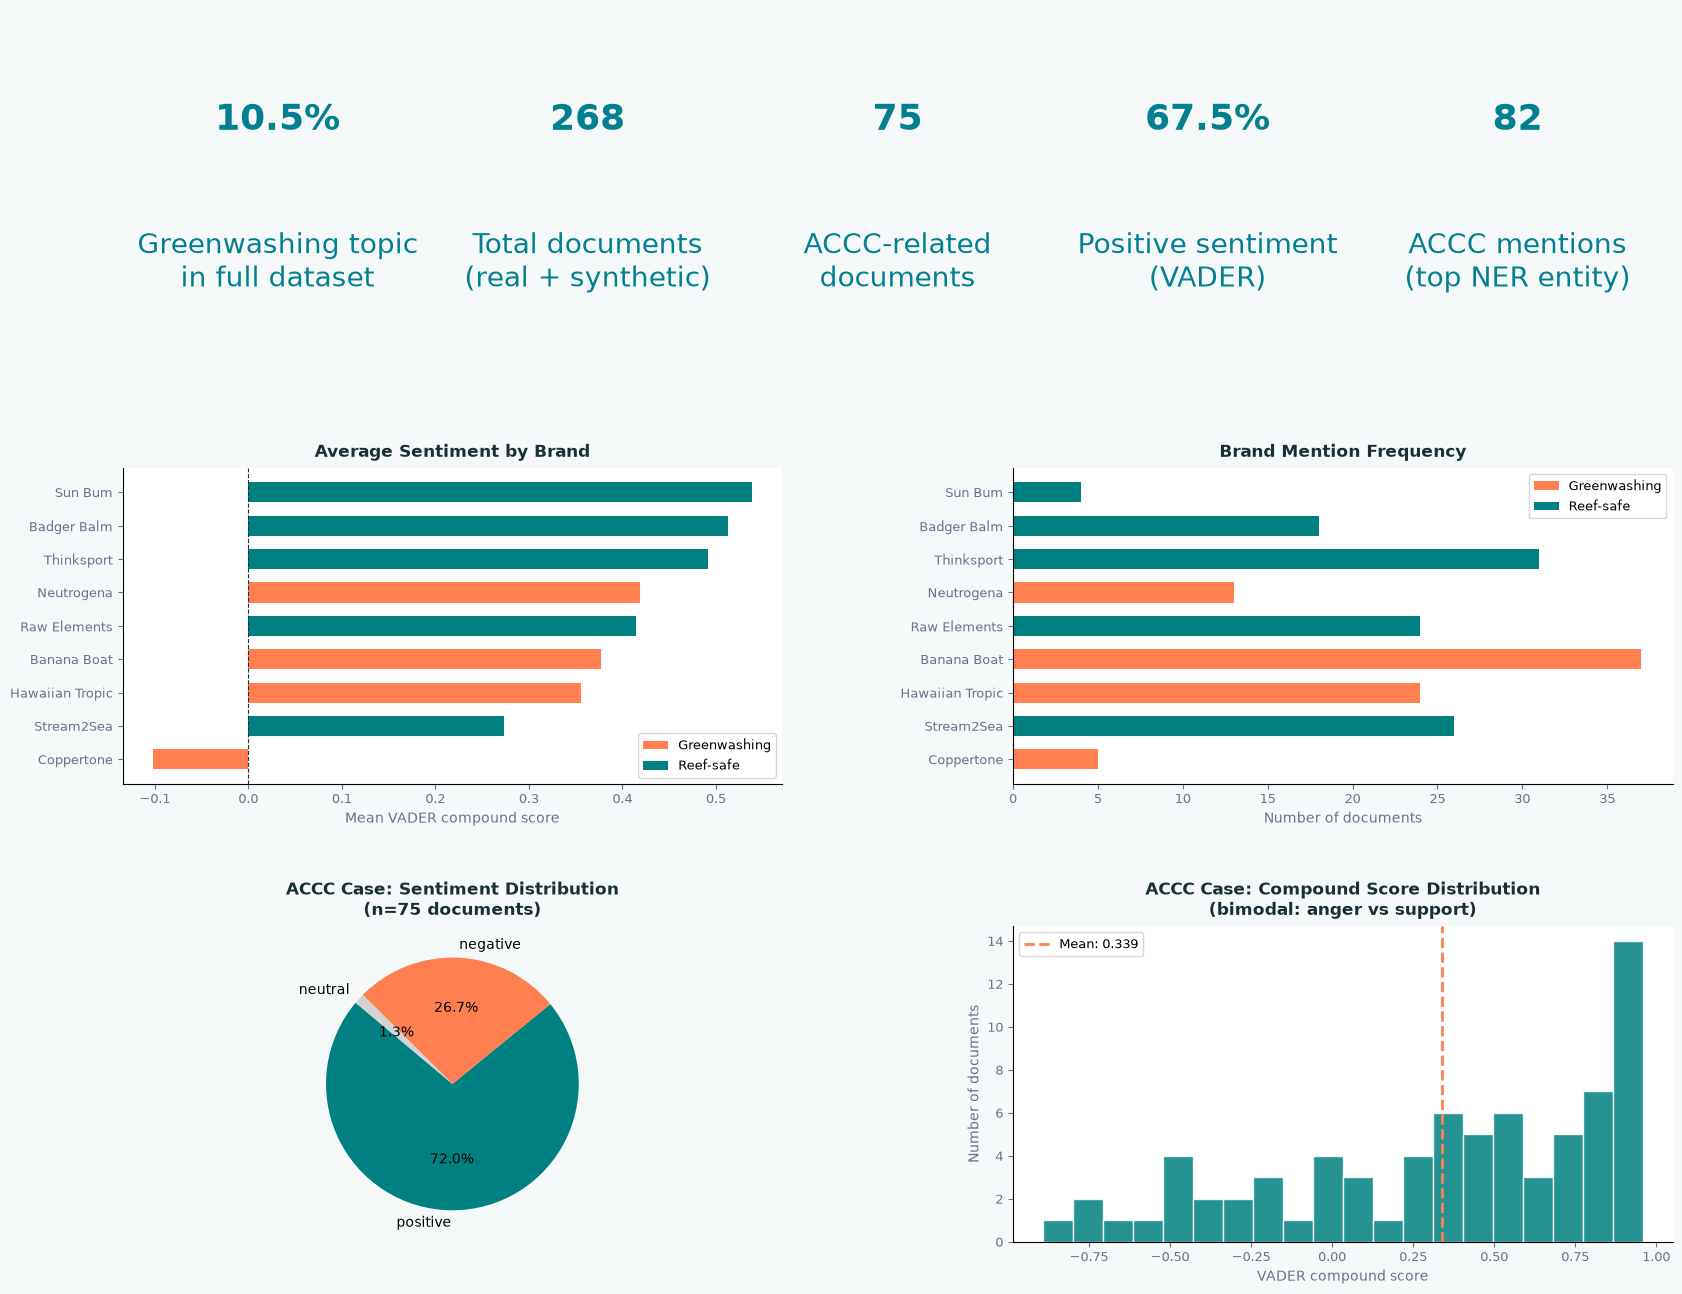

✓ Dashboard saved as ../figures/dashboard.png


In [78]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F5F9FA')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI BAR ──────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor('#1A2E35')
ax_kpi.axis('off')

kpis = [
    ("10.5%", "Greenwashing topic\nin full dataset"),
    ("268", "Total documents\n(real + synthetic)"),
    ("75", "ACCC-related\ndocuments"),
    ("67.5%", "Positive sentiment\n(VADER)"),
    ("82", "ACCC mentions\n(top NER entity)"),
]

for i, (val, label) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_kpi.text(x, 0.65, val, transform=ax_kpi.transAxes,
                fontsize=26, fontweight='bold', color='#028090',
                ha='center', va='center')
    ax_kpi.text(x, 0.2, label, transform=ax_kpi.transAxes,
                fontsize=20, color='#028090',
                ha='center', va='center')


# ── BRAND SENTIMENT ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('white')

colors_bar = ['coral' if c == 'Greenwashing' else 'teal'
              for c in brand_df['category']]
bars = ax1.barh(brand_df['brand'], brand_df['mean_sentiment'],
                color=colors_bar, height=0.6)
ax1.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean VADER compound score', fontsize=10, color='#64748B')
ax1.set_title('Average Sentiment by Brand', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax1.tick_params(colors='#64748B', labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
ax1.legend(handles=legend_elements, fontsize=9)

# ── BRAND MENTION FREQUENCY ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('white')

ax2.barh(brand_df['brand'], brand_df['count'],
         color=colors_bar, height=0.6)
ax2.set_xlabel('Number of documents', fontsize=10, color='#64748B')
ax2.set_title('Brand Mention Frequency', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax2.tick_params(colors='#64748B', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=legend_elements, fontsize=9)

# ── ACCC PIE CHART ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor('white')

sentiment_counts = df_accc['sentiment_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax3.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        textprops={'fontsize': 10})
ax3.set_title('ACCC Case: Sentiment Distribution\n(n=75 documents)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)

# ── ACCC HISTOGRAM ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor('white')

ax4.hist(df_accc['sentiment_score'], bins=20,
         color='teal', edgecolor='white', alpha=0.85)
ax4.axvline(x=df_accc['sentiment_score'].mean(),
            color='coral', linewidth=2, linestyle='--',
            label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
ax4.set_xlabel('VADER compound score', fontsize=10, color='#64748B')
ax4.set_ylabel('Number of documents', fontsize=10, color='#64748B')
ax4.set_title('ACCC Case: Compound Score Distribution\n(bimodal: anger vs support)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)
ax4.spines[['top', 'right']].set_visible(False)
ax4.tick_params(colors='#64748B', labelsize=9)
ax4.legend(fontsize=9)

plt.savefig('../figures/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F9FA')
plt.show()
print("✓ Dashboard saved as ../figures/dashboard.png")